## Load Libraries

In [1]:
# Ensure local package path is first
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import libraries
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import get_base_dir
import importlib

# Reload to pick up code changes
import galform_analysis.analysis.correlation.correlation as corr_module
import galform_analysis.analysis.correlation.plot_correlation as plot_corr_module

# Ensure we see latest code before symbol imports
importlib.reload(corr_module)
importlib.reload(plot_corr_module)

# Import updated functions after reload
from galform_analysis.analysis.correlation.plot_correlation import (
    plot_single_correlation,
    plot_correlation_multi_redshift,
    plot_avg_correlation_over_redshifts,
    plot_correlation_multi_redshift_avg_subvolumes,
)
from galform_analysis.analysis import correlation_given_redshift_and_subvolume

base_dir = get_base_dir()

# Plotting defaults (match compare_mass_functions style)
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

## 2PCF for a given snapshot and subvolume

[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?


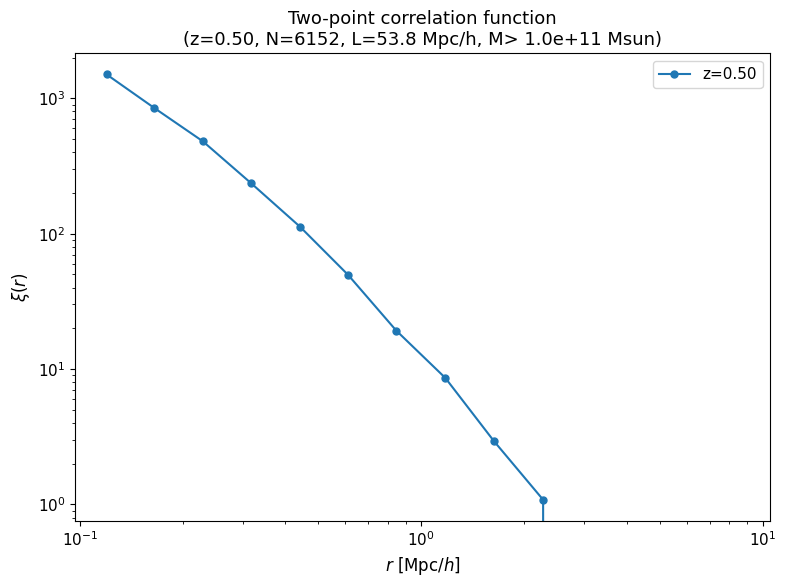

  Redshift: 0.4959
  N_gal: 6152
  Boxsize: 53.8 Mpc/h
  V_ivol: 1.556e+05 Mpc³

     r [Mpc/h]          ξ(r)
  --------------------------
          0.12   1502.696147
          0.23    482.045247
          0.44    113.567692
          0.85     20.260176
          1.63      3.942408
          3.17      0.523394
          6.15      0.007618
         11.83     -0.023308
         22.78     -0.003751


In [2]:
example_snapshot = 'iz207'
example_ivol = 100
snap_path = str(base_dir / example_snapshot)

# Define bin edges
rbins = np.logspace(np.log10(0.1), np.log10(50.0), 20)

# Optional: apply a minimum halo mass cut (Msun)
mhalo_min = 1e11  # e.g., 1e11 to keep halos >= 1e11 Msun

# Compute and plot using the module
result = plot_single_correlation(
    snap_path,
    example_ivol,
    rbins=rbins,
    nthreads=4,
    mhalo_min=mhalo_min,
    figsize=(8, 6),
    show_plot=True
)

if result is not None:
    print(f"  Redshift: {result['z']:.4f}")
    print(f"  N_gal: {result['ngal']}")
    print(f"  Boxsize: {result['boxsize']:.1f} Mpc/h")
    print(f"  V_ivol: {result['V_ivol']:.3e} Mpc³")
    print(f"\n  {'r [Mpc/h]':>12}  {'ξ(r)':>12}")
    print("  " + "-" * 26)
    r = result['r']
    xi = result['xi']
    for i in range(0, len(r), 2):
        if np.isfinite(xi[i]):
            print(f"  {r[i]:12.2f}  {xi[i]:12.6f}")

## 2PCF for one subvolume across multiple redshifts (overlay)

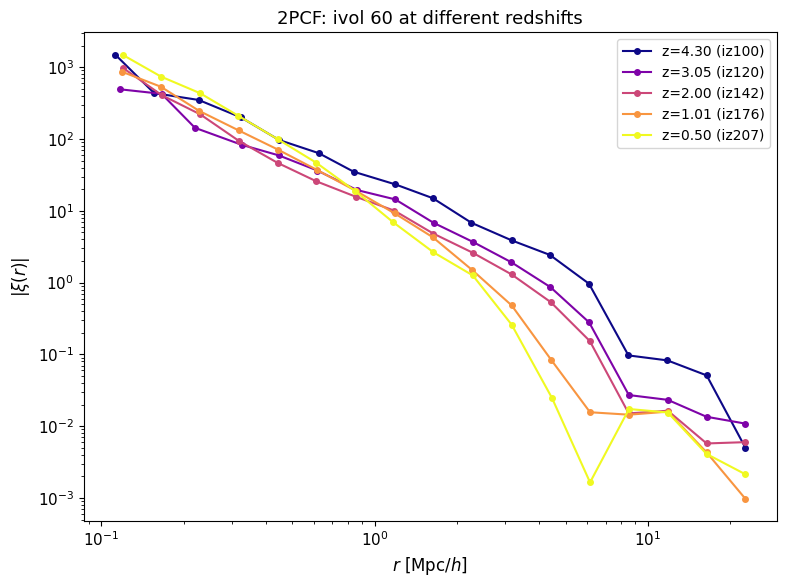

In [3]:
rbins = np.logspace(np.log10(0.1), np.log10(50.0), 20)
example_ivol = 60
iz_nums = [100, 120, 142, 176, 207]#, 271]
mhalo_min = 1e11

results = plot_correlation_multi_redshift(
    iz_nums=iz_nums,
    ivol=example_ivol,
    rbins=rbins,
    nthreads=4,
    show_plot=True,
    colormap='plasma',
    mhalo_min=mhalo_min,
)

## Average 2PCF over multiple redshifts for one subvolume

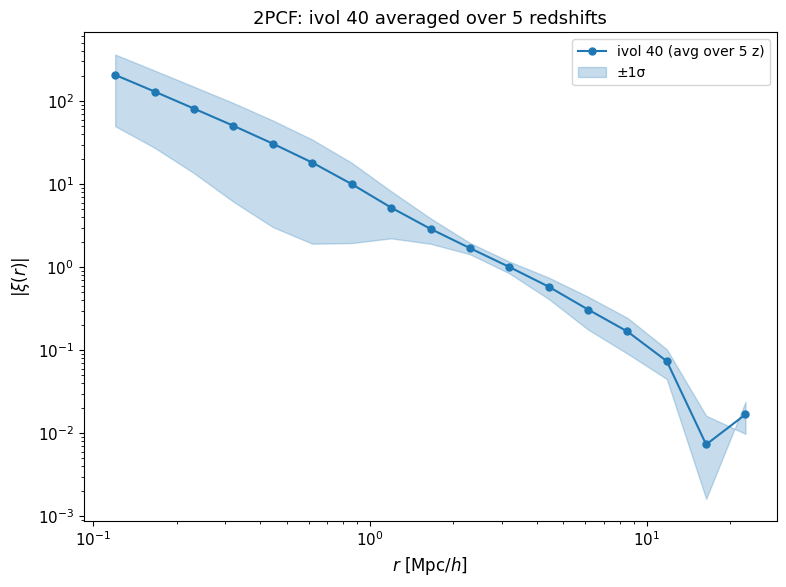

Averaged over 5 redshifts for ivol 40
First 5 (r, xi, xi_std):
     0.120  2.065703e+02  1.566735e+02
     0.166  1.302099e+02  1.027691e+02
     0.231  8.129686e+01  6.770108e+01
     0.321  5.039368e+01  4.426002e+01
     0.445  3.072293e+01  2.767940e+01


In [4]:
example_ivol = 40
iz_nums = [100, 120, 142, 176, 207]  

avg_result = plot_avg_correlation_over_redshifts(
    iz_nums=iz_nums,
    ivol=example_ivol,
    rbins=rbins,
    nthreads=4,
    show_plot=True,
)

if avg_result is not None:
    r = avg_result['r']
    xi = avg_result['xi']
    xi_std = avg_result.get('xi_std', None)
    n_used = avg_result.get('n_used', 0)

    print(f"Averaged over {n_used} redshifts for ivol {example_ivol}")
    if xi_std is not None:
        print("First 5 (r, xi, xi_std):")
        for i in range(min(5, len(r))):
            print(f"  {r[i]:8.3f}  {xi[i]:12.6e}  {xi_std[i]:12.6e}")


## 2PCF averaged over multiple subvolumes at different redshifts

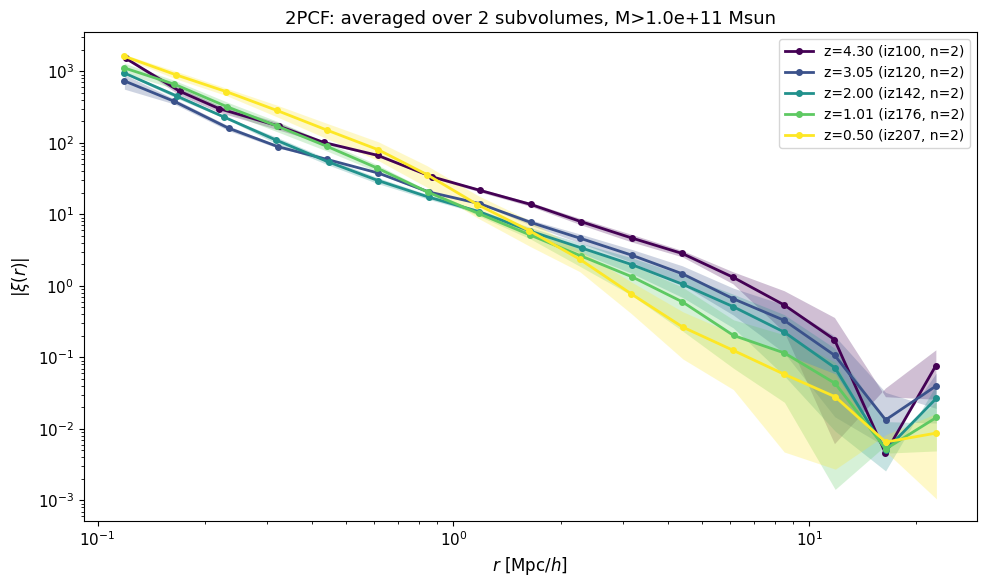

[{'iz': 'iz100',
  'z': 4.3009,
  'r': array([ 0.1198483 ,  0.17032708,  0.21925948,  0.32343632,  0.43156318,
          0.61261623,  0.86940757,  1.1875407 ,  1.65235289,  2.28424399,
          3.17458534,  4.39423749,  6.09661274,  8.49559331, 11.7634215 ,
         16.36257022, 22.67102883]),
  'xi': array([ 1.52612192e+03,  5.25336618e+02,  3.02353884e+02,  1.71324995e+02,
          1.01566309e+02,  6.69216451e+01,  3.36360899e+01,  2.16952188e+01,
          1.37579672e+01,  7.91644940e+00,  4.66810971e+00,  2.84182346e+00,
          1.32603317e+00,  5.41899785e-01,  1.77948599e-01, -4.58543566e-03,
         -7.69425669e-02]),
  'xi_std': array([2.52835438e+01, 8.91948579e+01, 4.75748354e+01, 2.89481038e+01,
         4.67038612e+00, 3.43091320e+00, 1.41839696e+00, 1.65317898e+00,
         1.22779367e+00, 1.11004668e+00, 7.97635160e-01, 4.09988818e-01,
         3.59454995e-01, 4.45050911e-01, 2.60464176e-01, 4.64223096e-02,
         7.19548119e-02]),
  'n_used': 2,
  'n_requested': 2

In [5]:
rbins = np.logspace(-1, np.log10(50), 20)
iz_nums = [100, 120, 142, 176, 207]
example_ivols = [40, 60]
mhalo_min = 1e11

plot_correlation_multi_redshift_avg_subvolumes(
    iz_nums=iz_nums,
    ivols=example_ivols,
    rbins=rbins,
    mhalo_min=mhalo_min,
    colormap='viridis',
    figsize=(10, 6)
)